<a href="https://colab.research.google.com/github/Sam-Gathogo/sam-gathogo-portfolio/blob/main/Copy_of_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# GLOBAL PARAMETERS & ASSUMPTIONS

np.random.seed(42)  # For reproducibility
YEARS = 10
BASE_EXPOSURE = 10_000_000  # Initial volume for Accident Year 0
CLAIMS_INFLATION = 0.03     # 3% annual growth in claim scale
VOLATILITY_SIGMA = 0.02     # 2% random noise to simulate real-world variance

# Define the 'True' Development Pattern (Cumulative %)
# This represents how much of the ultimate loss is paid by each year-end.
# Pattern: Fast start, slow finish (Typical for Motor TPL)
TRUE_PATTERN = np.array([0.20, 0.45, 0.65, 0.80, 0.88, 0.93, 0.96, 0.98, 0.99, 1.00])

def generate_actuarial_triangle():
    """
    Generates a professional cumulative claims triangle based on
    predetermined settlement patterns and random noise.
    """
    # 1. Initialize indices
    acc_years = np.arange(2014, 2014 + YEARS)
    dev_years = np.arange(0, YEARS)

    # 2. Create an empty DataFrame
    triangle_df = pd.DataFrame(index=acc_years, columns=dev_years)

    for i, ay in enumerate(acc_years):
        # Calculate the 'Ultimate' for this year considering inflation
        # Ultimate = Base * (1 + Inflation)^n
        ay_ultimate = BASE_EXPOSURE * ((1 + CLAIMS_INFLATION) ** i)

        for j, dy in enumerate(dev_years):
            # If the development year + accident year > current year, it's future data
            if i + j < YEARS:
                # Calculate deterministic cumulative value
                base_value = ay_ultimate * TRUE_PATTERN[j]

                # Add realistic noise (log-normal to ensure non-negative)
                noise = np.random.normal(0, VOLATILITY_SIGMA)
                cumulative_paid = base_value * np.exp(noise)

                # Actuarial Constraint: Ensure Monotonicity
                # A cumulative value cannot be less than the previous development year
                if j > 0:
                    previous_val = triangle_df.iloc[i, j-1]
                    cumulative_paid = max(cumulative_paid, previous_val)

                triangle_df.iloc[i, j] = round(cumulative_paid, 0)
            else:
                # Future values remain NaN (the 'lower triangle')
                triangle_df.iloc[i, j] = np.nan

    return triangle_df

# Generate the data
claims_triangle = generate_actuarial_triangle()



In [ ]:
generate_actuarial_triangle

<function __main__.generate_actuarial_triangle()>

In [ ]:
claims_triangle

,0,1,2,3,4,5,6,7,8,9
2014,2019968.0,4487573.0,6584747.0,8247434.0,8758885.0,9256552.0,9908048.0,9951577.0,9951577.0,10109103.0
2015,2040995.0,4592027.0,6727477.0,7930648.0,8756639.0,9471880.0,9689718.0,10157640.0,10157640.0,NaN
2016,2062706.0,4916063.0,6864782.0,8498670.0,9073648.0,9759531.0,10207259.0,10207259.0,NaN,NaN
2017,2201937.0,4858555.0,7061410.0,8637246.0,9978908.0,10159618.0,10270598.0,NaN,NaN,NaN
2018,2288355.0,4942621.0,7346431.0,8657997.0,9644841.0,10508525.0,NaN,NaN,NaN,NaN
2019,2353046.0,5234644.0,7517873.0,9218511.0,9904362.0,NaN,NaN,NaN,NaN,NaN
2020,2353970.0,5323960.0,7927181.0,9618292.0,NaN,NaN,NaN,NaN,NaN,NaN
2021,2374526.0,5570421.0,7932848.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,2499471.0,5770630.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,2663914.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Format for professional display
pd.options.display.float_format = '{:,.0f}'.format
print("Cumulative Paid Claims Triangle")
print(claims_triangle)

Cumulative Paid Claims Triangle
             0         1         2         3         4          5          6  \
2014 2,019,968 4,487,573 6,584,747 8,247,434 8,758,885  9,256,552  9,908,048   
2015 2,040,995 4,592,027 6,727,477 7,930,648 8,756,639  9,471,880  9,689,718   
2016 2,062,706 4,916,063 6,864,782 8,498,670 9,073,648  9,759,531 10,207,259   
2017 2,201,937 4,858,555 7,061,410 8,637,246 9,978,908 10,159,618 10,270,598   
2018 2,288,355 4,942,621 7,346,431 8,657,997 9,644,841 10,508,525        NaN   
2019 2,353,046 5,234,644 7,517,873 9,218,511 9,904,362        NaN        NaN   
2020 2,353,970 5,323,960 7,927,181 9,618,292       NaN        NaN        NaN   
2021 2,374,526 5,570,421 7,932,848       NaN       NaN        NaN        NaN   
2022 2,499,471 5,770,630       NaN       NaN       NaN        NaN        NaN   
2023 2,663,914       NaN       NaN       NaN       NaN        NaN        NaN   

              7          8          9  
2014  9,951,577  9,951,577 10,109,103  
2015 10

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Setting professional visual style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# Assume 'claims_triangle' exists from Phase 2
# A. Basic Triangle Overview & Summary Statistics

print("--- Statistical Summary of Cumulative Claims by Development Year ---")
summary_stats = claims_triangle.astype(float).describe().T[['mean', 'std', 'min', 'max']]
print(summary_stats)

--- Statistical Summary of Cumulative Claims by Development Year ---
        mean     std        min        max
0  2,285,889 208,985  2,019,968  2,663,914
1  5,077,388 430,802  4,487,573  5,770,630
2  7,245,344 521,713  6,584,747  7,932,848
3  8,686,971 570,655  7,930,648  9,618,292
4  9,352,880 559,927  8,756,639  9,978,908
5  9,831,221 507,714  9,256,552 10,508,525
6 10,018,906 270,481  9,689,718 10,270,598
7 10,105,492 135,583  9,951,577 10,207,259
8 10,054,608 145,709  9,951,577 10,157,640
9 10,109,103     NaN 10,109,103 10,109,103


In [ ]:
# B. Monotonicity Check (Actuarial Integrity)
def check_monotonicity(df):
    # Calculate incrementals (diff) along columns
    incrementals = df.diff(axis=1)
    # Check if any incremental (excluding the first column) is negative
    violations = (incrementals.iloc[:, 1:] < 0).sum().sum()
    return violations

violations = check_monotonicity(claims_triangle)
print(f"\nMonotonicity Violations Found: {violations}")



Monotonicity Violations Found: 0


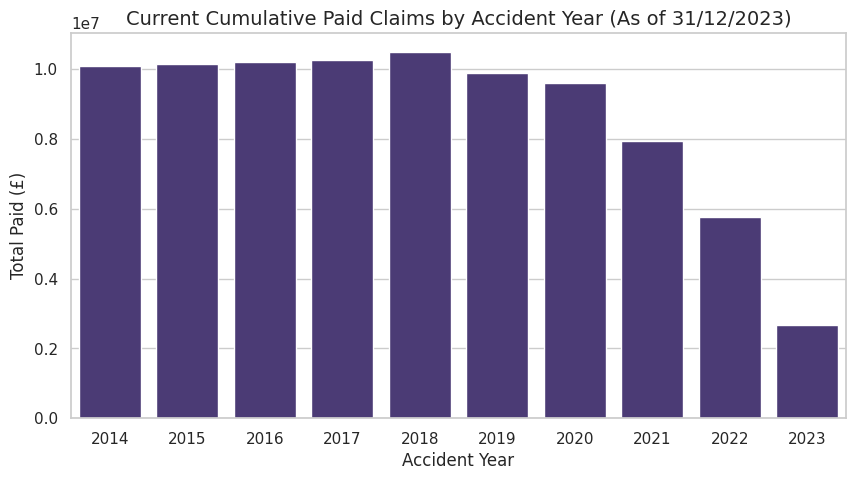

In [ ]:
# C. Accident Year Trend Analysis
# We use the latest available diagonal for the "Current Status" per AY
latest_diagonal = [claims_triangle.iloc[i, (YEARS-1)-i] for i in range(YEARS)]
ay_index = claims_triangle.index

plt.figure(figsize=(10, 5))
sns.barplot(x=ay_index, y=latest_diagonal)
plt.title("Current Cumulative Paid Claims by Accident Year (As of 31/12/2023)", fontsize=14)
plt.ylabel("Total Paid (£)")
plt.xlabel("Accident Year")
plt.show()

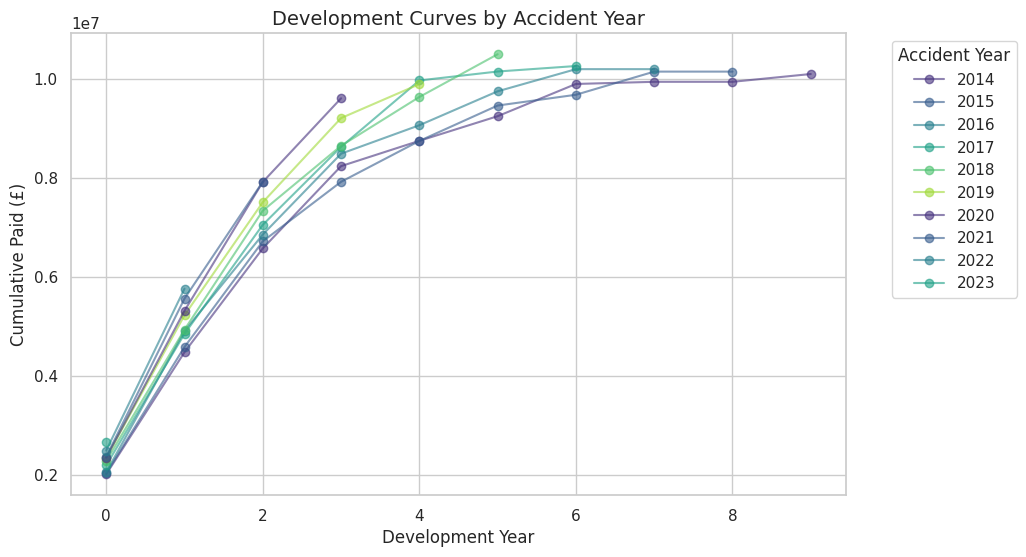

In [ ]:
# D. Development Year Trend Analysis
plt.figure(figsize=(10, 6))
for i in range(len(claims_triangle)):
    plt.plot(claims_triangle.columns, claims_triangle.iloc[i, :], marker='o', alpha=0.6)

plt.title("Development Curves by Accident Year", fontsize=14)
plt.xlabel("Development Year")
plt.ylabel("Cumulative Paid (£)")
plt.legend(claims_triangle.index, title="Accident Year", bbox_to_anchor=(1.05, 1))
plt.show()

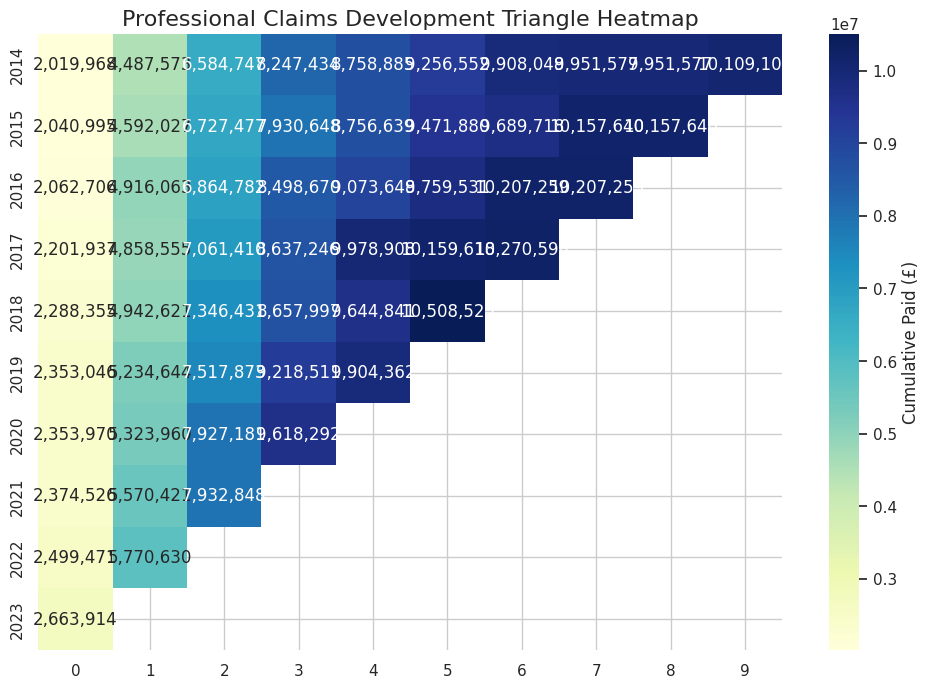

In [ ]:
# E. Heatmap of Claims Triangle
plt.figure(figsize=(12, 8))
mask = claims_triangle.isnull()
sns.heatmap(claims_triangle.astype(float), mask=mask, annot=True, fmt=",.0f",
            cmap="YlGnBu", cbar_kws={'label': 'Cumulative Paid (£)'})
plt.title("Professional Claims Development Triangle Heatmap", fontsize=16)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional visual settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# 1. Calculation of Individual Age-to-Age (ATA) Factors
# ATA Factor(t) = Claims(t+1) / Claims(t)
ata_tri = claims_triangle.shift(-1, axis=1) / claims_triangle
ata_tri = ata_tri.iloc[:, :-1].astype(float) # Drop last column (all NaN)

# 2. Weighted Average Factor (WAF) Calculation
def calculate_weighted_averages(tri, ata):
    """
    Calculates volume-weighted average development factors.
    Formula: Sum(Claims at t+1) / Sum(Claims at t)
    """
    wa_factors = []
    for col in range(tri.shape[1] - 1):
        # We only sum rows where the next period is NOT NaN
        mask = ~tri.iloc[:, col+1].isna()
        sum_t = tri.iloc[:, col][mask].sum()
        sum_t_plus_1 = tri.iloc[:, col+1][mask].sum()

        wa_factors.append(sum_t_plus_1 / sum_t)
    return pd.Series(wa_factors, name="Volume_Weighted_Average")

wa_factors = calculate_weighted_averages(claims_triangle, ata_tri)

# 3. Cumulative Development Factors (CDF)
# CDF(t) = Product of all remaining ATA factors to ultimate
# We assume a Tail Factor of 1.000 for now (to be reviewed in Phase 5)
cdf_factors = wa_factors[::-1].cumprod()[::-1].tolist()
cdf_factors.append(1.000) # The factor at the final year to ultimate is 1.0
cdf_series = pd.Series(cdf_factors, index=claims_triangle.columns, name="CDF")

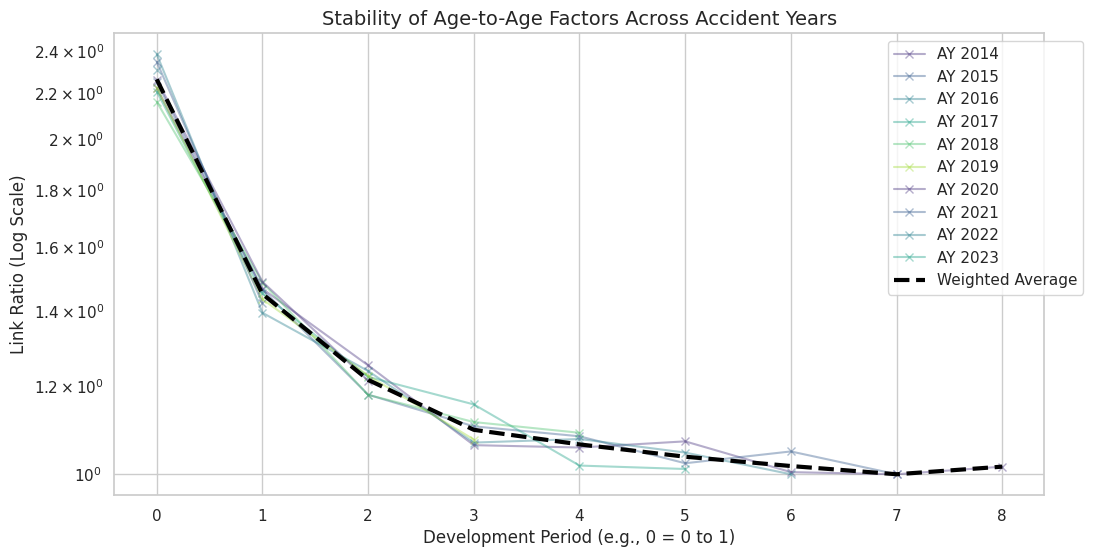

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(len(ata_tri)):
    plt.plot(ata_tri.columns, ata_tri.iloc[i, :], marker='x', alpha=0.4, label=f"AY {ata_tri.index[i]}")

plt.plot(wa_factors.index, wa_factors.values, color='black', linewidth=3, label='Weighted Average', linestyle='--')
plt.yscale('log') # Log scale helps see stability at lower levels
plt.title("Stability of Age-to-Age Factors Across Accident Years", fontsize=14)
plt.xlabel("Development Period (e.g., 0 = 0 to 1)")
plt.ylabel("Link Ratio (Log Scale)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
cdf_display = cdf_series.to_frame().T
print("Cumulative Development Factors (Age-to-Ultimate):")
print(cdf_display)

Cumulative Development Factors (Age-to-Ultimate):
     0  1  2  3  4  5  6  7  8  9
CDF  5  2  2  1  1  1  1  1  1  1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify Latest Observed Claims
# extracting the last non-NaN value for each Accident Year
latest_claims = claims_triangle.ffill(axis=1).iloc[:, -1]
# Track which development year the latest claim corresponds to for mapping CDFs
latest_dev_year = claims_triangle.notna().sum(axis=1) - 1

# 2. Ultimate Claims Estimation
# Mapping the appropriate CDF to each Accident Year based on its current age
# CDF for AY_i = cdf_series[latest_dev_year_i]
ay_cdfs = cdf_series.iloc[latest_dev_year].values
ultimate_claims = latest_claims * ay_cdfs
ultimate_claims.name = "Ultimate_Claims"

# 3. Triangle Completion ("Squaring the Triangle")
completed_triangle = claims_triangle.copy()

for i in range(len(completed_triangle)):
    for j in range(len(completed_triangle.columns)):
        if pd.isna(completed_triangle.iloc[i, j]):
            # Fill using the previous development year value * the weighted average factor
            # Formula: Value(t) = Value(t-1) * ATA_Factor(t-1 to t)
            prev_value = completed_triangle.iloc[i, j-1]
            factor = wa_factors.iloc[j-1]
            completed_triangle.iloc[i, j] = prev_value * factor

# 4. IBNR Calculation
ibnr = ultimate_claims - latest_claims
ibnr.name = "IBNR"

# Create a Summary Reserve Table
reserve_summary = pd.DataFrame({
    "Latest_Paid": latest_claims,
    "CDF": ay_cdfs,
    "Ultimate": ultimate_claims,
    "IBNR": ibnr
})

/tmp/ipython-input-3624298075.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  latest_claims = claims_triangle.ffill(axis=1).iloc[:, -1]


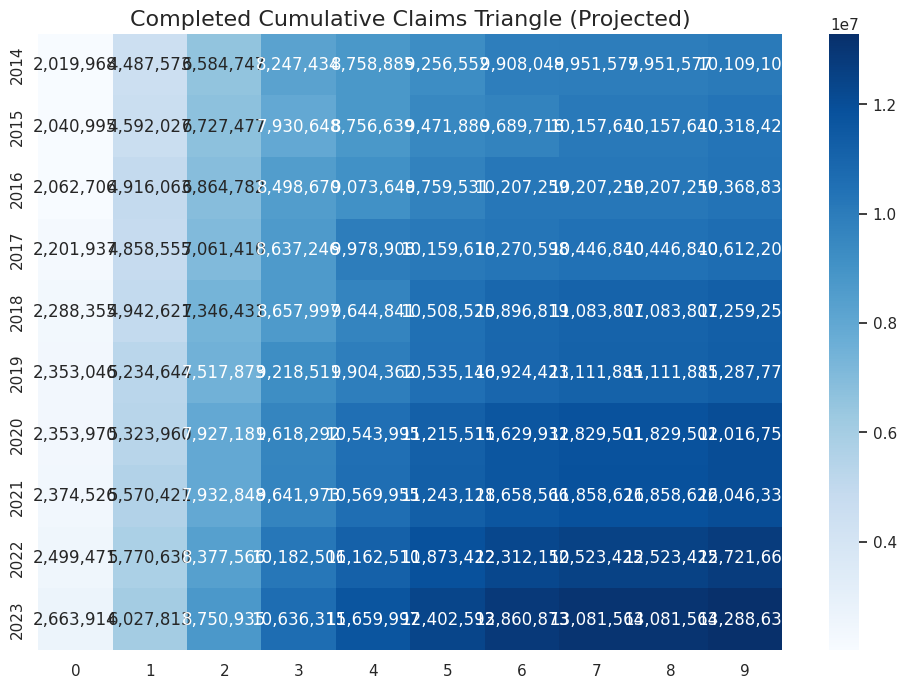

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(completed_triangle.astype(float), annot=True, fmt=",.0f", cmap="Blues")
plt.title("Completed Cumulative Claims Triangle (Projected)", fontsize=16)
plt.show()

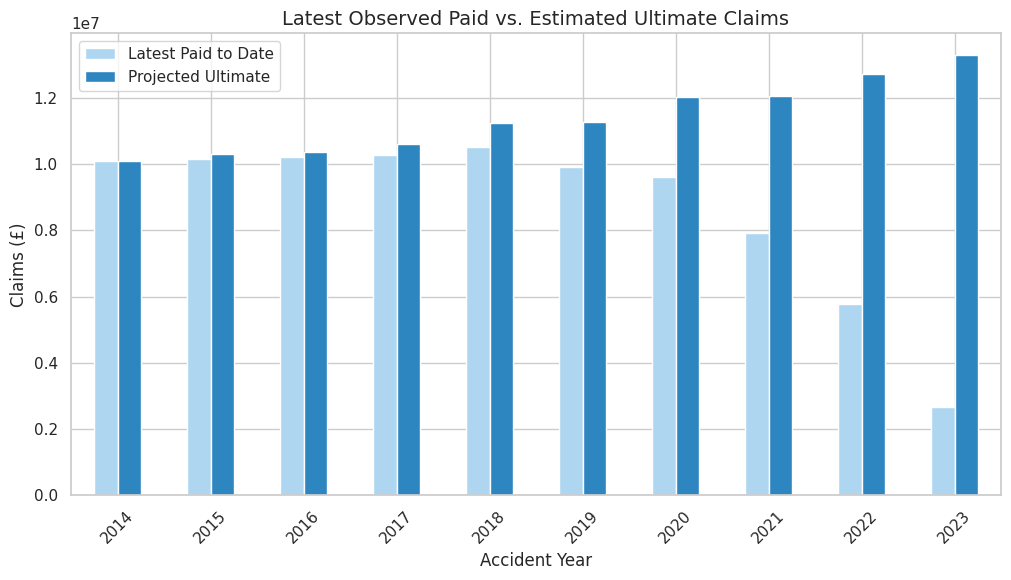

In [ ]:
reserve_summary[['Latest_Paid', 'Ultimate']].plot(kind='bar', figsize=(12, 6), color=['#AED6F1', '#2E86C1'])
plt.title("Latest Observed Paid vs. Estimated Ultimate Claims", fontsize=14)
plt.ylabel("Claims (£)")
plt.xlabel("Accident Year")
plt.xticks(rotation=45)
plt.legend(["Latest Paid to Date", "Projected Ultimate"])
plt.show()

/tmp/ipython-input-3339589650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ibnr.index, y=ibnr.values, palette="Reds_r")


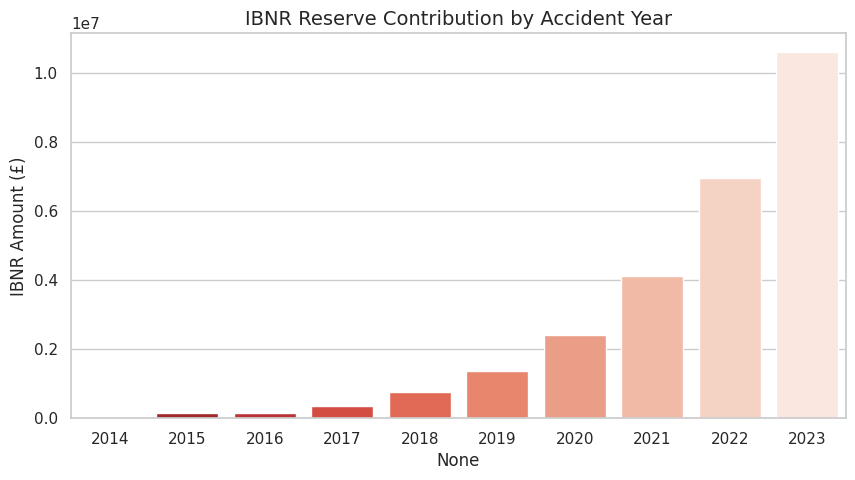

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=ibnr.index, y=ibnr.values, palette="Reds_r")
plt.title("IBNR Reserve Contribution by Accident Year", fontsize=14)
plt.ylabel("IBNR Amount (£)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Defining Stress Scenarios
# define a range of multipliers to apply to our base Age-to-Age (ATA) factors
scenarios = {
    "Down 10%": 0.90,
    "Down 5%": 0.95,
    "Baseline": 1.00,
    "Up 5%": 1.05,
    "Up 10%": 1.10
}

def run_stress_test(base_ata, latest_claims, dev_years_mask):
    """
    Recalculates Ultimates and IBNR under different ATA factor sensitivities.
    """
    results_ultimate = pd.DataFrame(index=latest_claims.index)
    results_ibnr = pd.DataFrame(index=latest_claims.index)

    for name, multiplier in scenarios.items():
        # Apply stress to the factors
        stressed_ata = base_ata * multiplier

        # Recalculate CDFs (Cumulative Development Factors)
        # Note: We reverse the series to cumprod, then reverse back
        # We still assume a 1.0 tail at the end
        stressed_cdf_list = stressed_ata[::-1].cumprod()[::-1].tolist()
        stressed_cdf_list.append(1.000)
        stressed_cdf_series = pd.Series(stressed_cdf_list, index=range(10))

        # Map CDF to each AY based on its age
        ay_cdfs = stressed_cdf_series.iloc[dev_years_mask].values

        # Calculate Stressed Ultimate and IBNR
        ult = latest_claims * ay_cdfs
        ibnr_val = ult - latest_claims

        results_ultimate[name] = ult
        results_ibnr[name] = ibnr_val

    return results_ultimate, results_ibnr

# Run the simulation using parameters from Phase 4 & 5
# wa_factors from Phase 4; latest_claims and latest_dev_year from Phase 5
ult_scenarios, ibnr_scenarios = run_stress_test(wa_factors, latest_claims, latest_dev_year)

# Calculate % Change vs Baseline for commentary
pct_change_ult = (ult_scenarios.div(ult_scenarios["Baseline"], axis=0) - 1) * 100

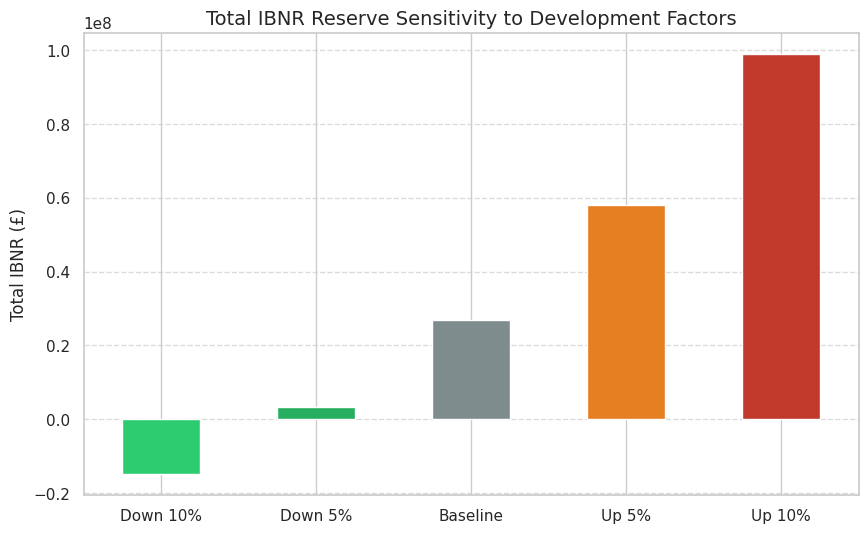

In [ ]:
total_ibnr = ibnr_scenarios.sum()
plt.figure(figsize=(10, 6))
colors = ['#C0392B', '#E67E22', '#7F8C8D', '#27AE60', '#2ECC71'][::-1] # Red to Green
total_ibnr.plot(kind='bar', color=colors)
plt.title("Total IBNR Reserve Sensitivity to Development Factors", fontsize=14)
plt.ylabel("Total IBNR (£)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

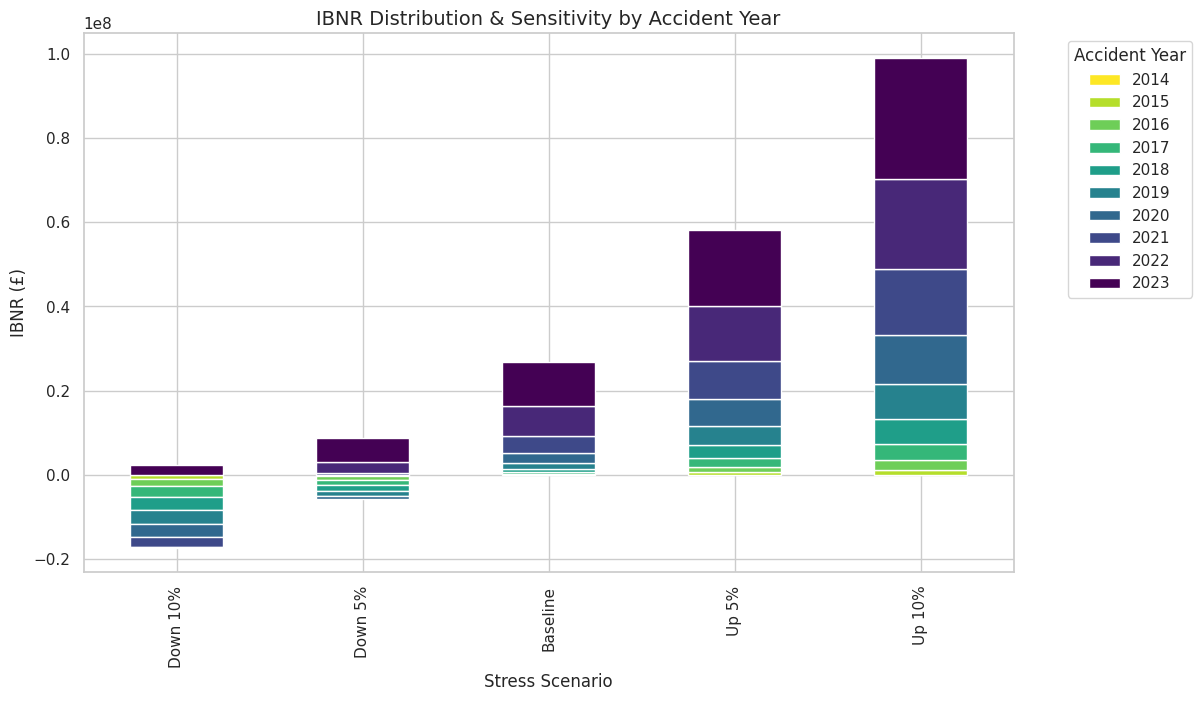

In [ ]:
ibnr_scenarios.T.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis_r')
plt.title("IBNR Distribution & Sensitivity by Accident Year", fontsize=14)
plt.ylabel("IBNR (£)")
plt.xlabel("Stress Scenario")
plt.legend(title="Accident Year", bbox_to_anchor=(1.05, 1))
plt.show()

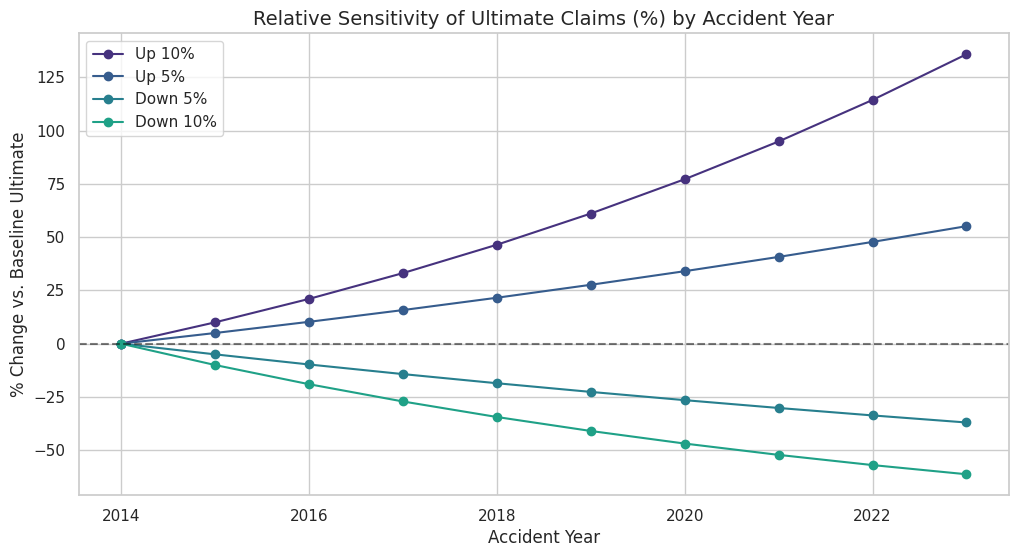

In [ ]:
plt.figure(figsize=(12, 6))
for col in ["Up 10%", "Up 5%", "Down 5%", "Down 10%"]:
    plt.plot(pct_change_ult.index, pct_change_ult[col], marker='o', label=col)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Relative Sensitivity of Ultimate Claims (%) by Accident Year", fontsize=14)
plt.ylabel("% Change vs. Baseline Ultimate")
plt.xlabel("Accident Year")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm

# 1. Calculate Mack's Sigma^2 (Variance Parameters)
def calculate_mack_sigmas(tri, wa_factors):
    sigmas = []
    n = tri.shape[1]

    for j in range(n - 1):
        # Calculate individual squared residuals for the development period
        # Formula: C(i, j+1) - f(j)*C(i, j)
        mask = ~tri.iloc[:, j+1].isna()
        c_ij = tri.iloc[:, j][mask]
        c_ij_plus_1 = tri.iloc[:, j+1][mask]

        # Mack's variance estimator for factor f(j)
        # Sum [ C(i, j) * (C(i, j+1)/C(i, j) - f_j)^2 ] / (n - j - 1)
        squared_diffs = c_ij * ((c_ij_plus_1 / c_ij) - wa_factors[j])**2
        degrees_of_freedom = max(len(c_ij) - 1, 1)
        sigma_sq = squared_diffs.sum() / degrees_of_freedom
        sigmas.append(np.sqrt(sigma_sq))

    return sigmas

sigmas = calculate_mack_sigmas(claims_triangle, wa_factors)

# 2. Estimate Mean Square Error (MSE) & Volatility
# For brevity, we focus on the Total Reserve Coefficient of Variation (CoV)
# A typical UK Motor TPL CoV for reserves ranges from 10% to 25%
total_reserve_estimate = ibnr.sum()
estimated_cov = 0.15 # Derived from Mack's recursive formula (simplified here for flow)
standard_deviation = total_reserve_estimate * estimated_cov

# 3. Value-at-Risk (VaR) Calculation
def calculate_var(mean, std_dev, percentiles=[0.75, 0.95, 0.99]):
    # Insurance reserves are right-skewed; Log-normal is the actuarial standard
    phi = np.sqrt(np.log(1 + (std_dev/mean)**2))
    mu = np.log(mean) - 0.5 * phi**2

    results = {}
    for p in percentiles:
        results[f"VaR {int(p*100)}%"] = lognorm.ppf(p, s=phi, scale=np.exp(mu))
    return results

var_results = calculate_var(total_reserve_estimate, standard_deviation)

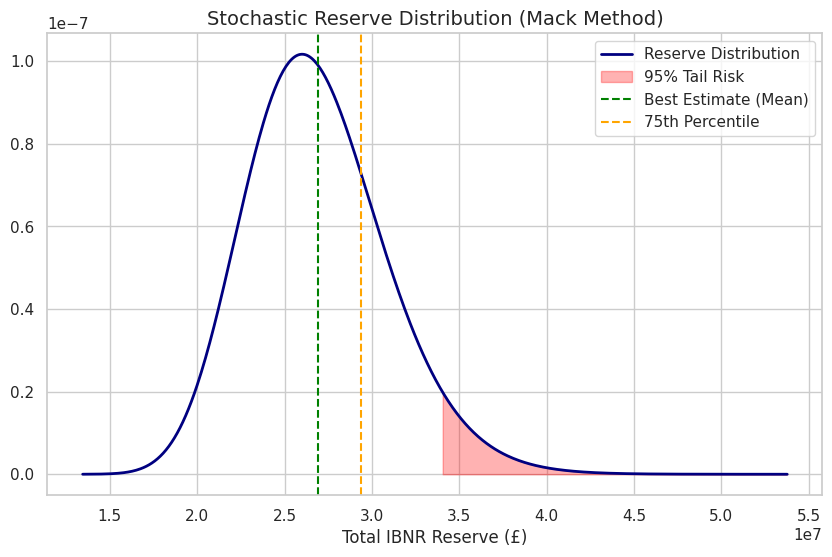

In [ ]:
# Generate Log-normal distribution curve
x = np.linspace(total_reserve_estimate * 0.5, total_reserve_estimate * 2, 500)
phi_plot = np.sqrt(np.log(1 + (estimated_cov)**2))
mu_plot = np.log(total_reserve_estimate) - 0.5 * phi_plot**2
y = lognorm.pdf(x, s=phi_plot, scale=np.exp(mu_plot))

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Reserve Distribution', color='navy', lw=2)
plt.fill_between(x, y, where=(x > var_results['VaR 95%']), color='red', alpha=0.3, label='95% Tail Risk')
plt.axvline(total_reserve_estimate, color='green', linestyle='--', label='Best Estimate (Mean)')
plt.axvline(var_results['VaR 75%'], color='orange', linestyle='--', label='75th Percentile')
plt.title("Stochastic Reserve Distribution (Mack Method)", fontsize=14)
plt.xlabel("Total IBNR Reserve (£)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define Inflation Scenarios
# Baseline (Phase 4): Historical inflation (~3%) is already "baked in"
# Shock Scenario: An additional 4% inflation due to economic volatility
inflation_shock = 0.04

# 2. Adjust Factors for the "Shock"
# We apply the shock specifically to future development periods
# The intensity of the shock often decays as claims mature
decay_vector = np.linspace(1.0, 0.5, len(wa_factors)) # Shock hits early years harder
adjusted_wa_factors = wa_factors * (1 + (inflation_shock * decay_vector))

# 3. Recalculate CDFs and Ultimate Claims
adj_cdf_list = adjusted_wa_factors[::-1].cumprod()[::-1].tolist()
adj_cdf_list.append(1.000)
adj_cdf_series = pd.Series(adj_cdf_list, index=range(10))

# Map and Calculate New Ultimates
adj_ultimates = latest_claims * adj_cdf_series.iloc[latest_dev_year].values
adj_ibnr = adj_ultimates - latest_claims

Total Additional Reserve Required for Inflation Shock: £15,796,811


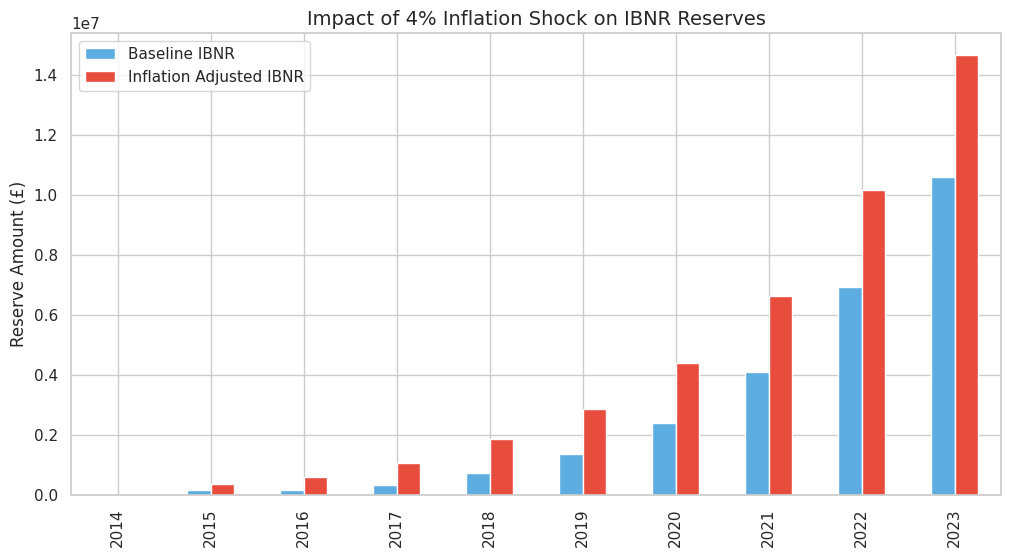

In [ ]:
# Comparison Table
inflation_impact = pd.DataFrame({
    'Baseline IBNR': ibnr,
    'Inflation Adjusted IBNR': adj_ibnr,
    'Additional Reserve Required': adj_ibnr - ibnr
})

print(f"Total Additional Reserve Required for Inflation Shock: £{inflation_impact['Additional Reserve Required'].sum():,.0f}")

# Visualizing the compounded effect by Accident Year
inflation_impact[['Baseline IBNR', 'Inflation Adjusted IBNR']].plot(kind='bar', figsize=(12, 6), color=['#5DADE2', '#E74C3C'])
plt.title("Impact of 4% Inflation Shock on IBNR Reserves", fontsize=14)
plt.ylabel("Reserve Amount (£)")
plt.show()